In [4]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.cluster import KMeans

from sklearn.metrics import silhouette_score

import matplotlib.pyplot as plt

In [5]:
learner_profile = pd.read_csv(
    "../outputs/learner_profile.csv"
)

In [3]:
learner_profile.head()

,UserID,TotalCourses,TotalSpending,CategoryDiversity,AvgRating,PreferredCategory,PreferredLevel
0,U00001,1,394.26,1,1.350000,Cybersecurity,Intermediate
1,U00002,1,0.00,1,2.880000,Programming,Beginner
2,U00003,11,613.98,7,2.889091,Marketing,Advanced
3,U00004,13,982.05,8,3.451538,Digital Marketing,Intermediate
4,U00005,2,346.71,2,2.055000,Programming,Advanced


In [4]:
le_category = LabelEncoder()

learner_profile["PreferredCategory"] = (
    le_category.fit_transform(
        learner_profile["PreferredCategory"]
    )
)

In [5]:
le_level = LabelEncoder()

learner_profile["PreferredLevel"] = (
    le_level.fit_transform(
        learner_profile["PreferredLevel"]
    )
)

In [6]:
learner_profile.head()

,UserID,TotalCourses,TotalSpending,CategoryDiversity,AvgRating,PreferredCategory,PreferredLevel
0,U00001,1,394.26,1,1.350000,2,2
1,U00002,1,0.00,1,2.880000,9,1
2,U00003,11,613.98,7,2.889091,8,0
3,U00004,13,982.05,8,3.451538,5,2
4,U00005,2,346.71,2,2.055000,9,0


In [7]:
X = learner_profile.drop(
    columns=["UserID"]
)

In [8]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [9]:
inertia = []

for k in range(2,11):

    model = KMeans(
        n_clusters=k,
        random_state=42
    )

    model.fit(X_scaled)

    inertia.append(
        model.inertia_
    )

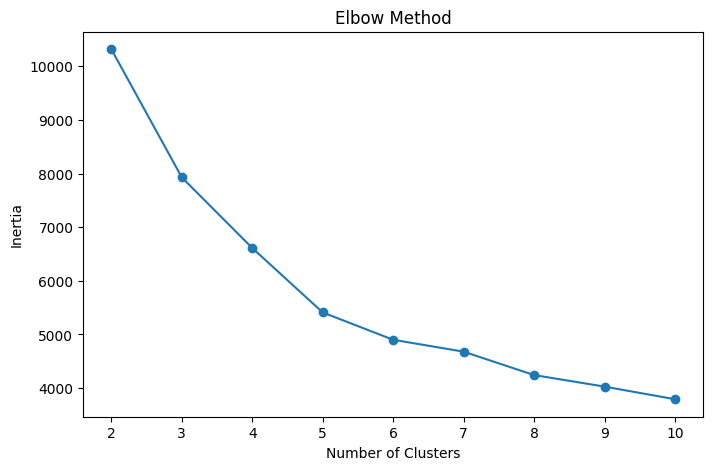

In [10]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

In [11]:
sil_scores = []

for k in range(2,11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    sil_scores.append(score)

    print(
        f"K={k}, Silhouette={score:.4f}"
    )

K=2, Silhouette=0.5134
K=3, Silhouette=0.3002
K=4, Silhouette=0.3007
K=5, Silhouette=0.3303
K=6, Silhouette=0.3171
K=7, Silhouette=0.3309
K=8, Silhouette=0.2906
K=9, Silhouette=0.2833
K=10, Silhouette=0.2676


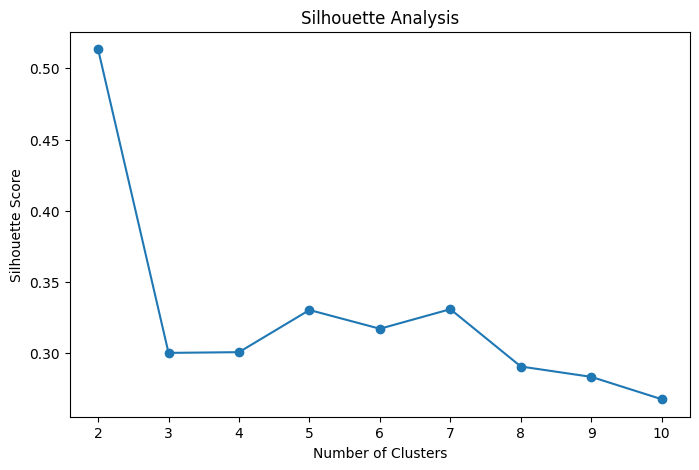

In [12]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    sil_scores,
    marker="o"
)

plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")

plt.show()

In [13]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

learner_profile["Cluster"] = kmeans.fit_predict(X_scaled)

In [14]:
learner_profile["Cluster"].value_counts()

Cluster
3    700
2    693
4    614
0    541
1    452
Name: count, dtype: int64

In [15]:
cluster_summary = learner_profile.groupby(
    "Cluster"
).mean(numeric_only=True)

cluster_summary

,TotalCourses,TotalSpending,CategoryDiversity,AvgRating,PreferredCategory,PreferredLevel
Cluster,,,,,,
0,1.264325,66.562606,1.190388,2.006990,8.060998,0.576710
1,13.415929,1253.570288,8.743363,3.115493,3.712389,0.690265
2,1.883117,175.438095,1.821068,3.071042,2.572872,0.000000
3,1.678571,212.017386,1.624286,3.058168,1.667143,1.491429
4,1.257329,63.043257,1.200326,4.295570,7.231270,1.211726


In [16]:
cluster_summary.round(2)

,TotalCourses,TotalSpending,CategoryDiversity,AvgRating,PreferredCategory,PreferredLevel
Cluster,,,,,,
0,1.26,66.56,1.19,2.01,8.06,0.58
1,13.42,1253.57,8.74,3.12,3.71,0.69
2,1.88,175.44,1.82,3.07,2.57,0.00
3,1.68,212.02,1.62,3.06,1.67,1.49
4,1.26,63.04,1.20,4.30,7.23,1.21


In [17]:
cluster_names = {
    0: "Inactive Learners",
    1: "Premium Power Learners",
    2: "Beginner Learners",
    3: "Career Focused Learners",
    4: "Quality Seekers"
}

learner_profile["Segment"] = (
    learner_profile["Cluster"]
    .map(cluster_names)
)

In [18]:
learner_profile.head()

,UserID,TotalCourses,TotalSpending,CategoryDiversity,AvgRating,PreferredCategory,PreferredLevel,Cluster,Segment
0,U00001,1,394.26,1,1.350000,2,2,3,Career Focused Learners
1,U00002,1,0.00,1,2.880000,9,1,0,Inactive Learners
2,U00003,11,613.98,7,2.889091,8,0,1,Premium Power Learners
3,U00004,13,982.05,8,3.451538,5,2,1,Premium Power Learners
4,U00005,2,346.71,2,2.055000,9,0,0,Inactive Learners


In [19]:
learner_profile.to_csv(
    "../outputs/learner_profile.csv",
    index=False
)

In [1]:
from sklearn.decomposition import PCA

In [6]:
features = learner_profile[
    [
        "TotalCourses",
        "TotalSpending",
        "CategoryDiversity",
        "AvgRating"
    ]
]

In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_features = scaler.fit_transform(
    features
)

In [8]:
pca = PCA(
    n_components=2
)

pca_result = pca.fit_transform(
    scaled_features
)

In [9]:
learner_profile["PCA1"] = pca_result[:,0]

learner_profile["PCA2"] = pca_result[:,1]

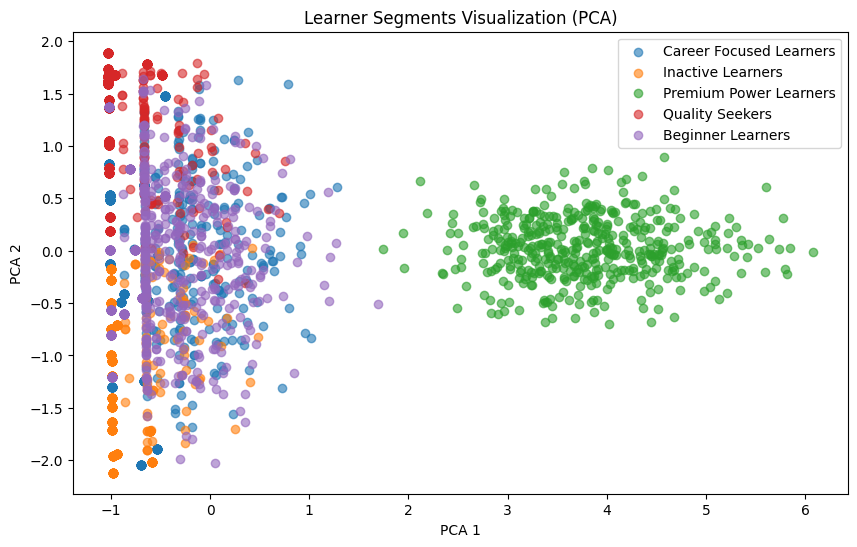

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

for segment in learner_profile["Segment"].unique():

    temp = learner_profile[
        learner_profile["Segment"] == segment
    ]

    plt.scatter(
        temp["PCA1"],
        temp["PCA2"],
        label=segment,
        alpha=0.6
    )

plt.title(
    "Learner Segments Visualization (PCA)"
)

plt.xlabel("PCA 1")

plt.ylabel("PCA 2")

plt.legend()

plt.show()

In [11]:
learner_profile.to_csv(
    "../outputs/final_learner_profile.csv",
    index=False
)

print("File Saved Successfully")

File Saved Successfully


In [12]:
import os

os.path.exists(
    "../outputs/final_learner_profile.csv"
)

True

In [14]:
from sklearn.decomposition import PCA
import pandas as pd

# PCA ke liye features
features = learner_profile[
    [
        "TotalCourses",
        "TotalSpending",
        "CategoryDiversity",
        "AvgRating"
    ]
]

# PCA
pca = PCA(n_components=2)

pca_result = pca.fit_transform(features)

# DataFrame banao
pca_df = pd.DataFrame(
    pca_result,
    columns=["PCA1", "PCA2"]
)

# Segment add karo
pca_df["Segment"] = learner_profile["Segment"]

# Save
pca_df.to_csv(
    "../outputs/pca_visualization.csv",
    index=False
)

print("PCA CSV Saved Successfully")

PCA CSV Saved Successfully


In [15]:
pca_df.head()

,PCA1,PCA2,Segment
0,90.456827,-3.633903,Career Focused Learners
1,-303.787499,-0.102677,Inactive Learners
2,310.272172,6.071284,Premium Power Learners
3,678.347356,5.011937,Premium Power Learners
4,42.920996,-1.826005,Inactive Learners


In [ ]:
import os

os.path.exists(
    "../outputs/pca_visualization.csv"
)

True

: 